https://www.kaggle.com/code/mingdi22/deep-learning-tutorial-for-beginners/notebook

# 数据集概述

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
from subprocess import check_output
print(check_output(["ls", "input"]).decode('utf8'))

X.npy
Y.npy



(-0.5, 63.5, 63.5, -0.5)

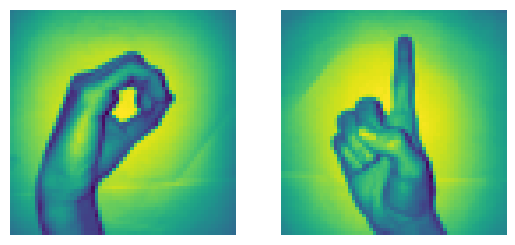

In [2]:
x_1 = np.load('input/X.npy')
Y_1 = np.load('input/Y.npy')
img_size = 64

plt.subplot(1, 2, 1)
plt.imshow(x_1[260].reshape(img_size, img_size))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(x_1[900].reshape(img_size, img_size))
plt.axis('off')

In [3]:
X = np.concatenate((x_1[204:409], x_1[822:1027]),axis=0)
z = np.zeros(205)
o = np.ones(205)
Y = np.concatenate((z, o), axis=0).reshape(X.shape[0], 1)

In [4]:
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (410, 64, 64)
Y shape: (410, 1)


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
number_of_train = X_train.shape[0]
number_of_test = X_test.shape[0]

In [7]:
print(number_of_train)
print(number_of_test)

348
62


In [8]:
X_train.shape[1], X_train.shape[2]

(64, 64)

In [9]:
X_train_flatten = X_train.reshape(number_of_train, X_train.shape[1]*X_train.shape[2])

In [10]:
X_train_flatten.shape

(348, 4096)

In [11]:
X_test_flatten = X_test.reshape(number_of_test, X_test.shape[1]*X_test.shape[2])

In [12]:
X_test_flatten.shape

(62, 4096)

In [13]:
x_train = X_train_flatten.T
x_test = X_test_flatten.T
y_train = Y_train.T
y_test = Y_test.T

In [14]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

x_train: (4096, 348)
x_test: (4096, 62)
y_train (1, 348)
y_test (1, 62)


# 逻辑回归

In [15]:
def dummy(parameter):
    dummy_parameter = parameter + 5
    return dummy_parameter
result = dummy(3)
result

8

初始化w, b

In [16]:
def initialize_weights_and_bias(dimension):
    w = np.full((dimension, 1), 0.01)
    b = 0.0
    return w, b

## 前向传播

定义sigmoid函数

In [17]:
def sigmoid(z):
    y_head = 1/(1+np.exp(-z))
    return y_head

In [18]:
y_head = sigmoid(0)
y_head

0.5

损失函数

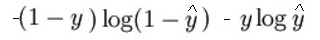

In [19]:
x_train.shape, y_train.shape

((4096, 348), (1, 348))

In [20]:
def forward_propagation(w, b, x_train, y_train):
    z = np.dot(w.T, x_train) + b
    y_head = sigmoid(z)
#     print(y_head.shape, y_train.shape, )
    loss = -y_train*np.log(y_head) - (1-y_train)*np.log(1-y_head)
#     print(loss.shape)
    cost = (np.sum(loss))/x_train.shape[1]
    
    return cost

剃度下降优化算法

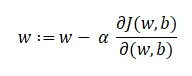

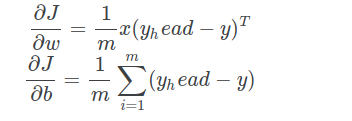

In [21]:
def forward_backward_propagation(w, b, x_train, y_train):
    
    z = np.dot(w.T, x_train) + b
    
    y_head = sigmoid(z)
    
    loss = -y_train*np.log(y_head)- (1-y_train)*np.log(1-y_head)
    
    cost = (np.sum(loss))/x_train.shape[1]
    
    derivative_weight = (np.dot(x_train, ((y_head-y_train).T)))/x_train.shape[1]
    derivative_bias = np.sum(y_head-y_train) / x_train.shape[1]
    
    gradients = {"derivative_weight":derivative_weight, 
                "derivative_bias":derivative_bias}
    return cost, gradients

## 更新参数（权重和偏差)

这段代码定义了一个名为 `update` 的函数，主要用于更新机器学习模型的权重和偏置。下面我将逐行解释这段代码的每个部分：

```python
def update(w, b, x_train, y_train, learning_rate, number_of_iterarion):
```
- 定义一个函数 `update`，接受一些参数：
  - `w`: 权重（weights）
  - `b`: 偏置（bias）
  - `x_train`: 训练数据（features）
  - `y_train`: 训练标签（targets）
  - `learning_rate`: 学习率（控制每次更新的步长）
  - `number_of_iterarion`: 迭代次数（在训练中循环的次数）

```python
    cost_list = []
    cost_list2 = []
    index = []
```
- 初始化三个空列表：
  - `cost_list`: 用于存储每次迭代的成本（cost）。
  - `cost_list2`: 用于存储每10次迭代的成本，后续将用于画图。
  - `index`: 用于记录哪些迭代时的成本被存储，以便于绘图。

```python
    for i in range(number_of_iterarion):
```
- 开始一个循环，迭代 `number_of_iterarion` 次。

```python
        cost, gradients = forward_backward_propagation(w, b, x_train, y_train)
```
- 调用 `forward_backward_propagation` 函数，计算当前的成本（cost）和梯度（gradients），用以更新权重和偏置。

```python
        cost_list.append(cost)
```
- 将当前迭代的成本添加到 `cost_list` 中。

```python
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]
```
- 根据计算出的梯度更新权重和偏置：
  - 权重更新为当前权重减去学习率乘以权重的导数。
  - 偏置更新为当前偏置减去学习率乘以偏置的导数。

```python
        if i % 10 == 0:
```
- 每经过10次迭代，执行以下操作：

```python
            cost_list2.append(cost)
            index.append(i)
```
- 将成本存储到 `cost_list2` 中，并将当前迭代次数存储到 `index` 中，以便后续绘图。

```python
            print("cost after iteration %i: %f"%(i, cost))
```
- 输出当前迭代次数和对应的成本，格式化为字符串。

```python
    parameters = {"weight":w, "bias":b}
```
- 将更新后的权重和偏置打包成一个字典 `parameters`。

```python
    plt.plot(index, cost_list2)
```
- 使用 Matplotlib 库绘制成本随迭代次数变化的图表。

```python
    plt.xticks(index, rotation='vertical')
```
- 设置 x 轴刻度为 `index`，并将刻度标签旋转为垂直方向以便更好地显示。

```python
    plt.xlabel("Number of Iterarion")
    plt.ylabel("cost")
```
- 设置 x 轴和 y 轴的标签。

```python
    plt.show()
```
- 显示绘制的图表。

```python
    return parameters, gradients, cost_list
```
- 返回更新后的权重和偏置、计算得到的梯度以及所有迭代的成本列表。

总体来说，这个函数通过多次迭代更新模型的参数（权重和偏置），并在过程中过滤并记录成本，以便绘图和分析。


In [22]:
def update(w, b, x_train, y_train, learning_rate, number_of_iterarion):
    cost_list = []
    cost_list2 = []
    index = []
    
    for i in range(number_of_iterarion):
        cost, gradients = forward_backward_propagation(w, b, x_train, y_train)
        cost_list.append(cost)
        
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]
        
        if i % 10 == 0:
            cost_list2.append(cost)
            index.append(i)
            print("cost after iteration %i: %f"%(i, cost))
    
    parameters = {"weight":w, "bias":b}
    plt.plot(index, cost_list2)
    plt.xticks(index, rotation='vertical')
    plt.xlabel("Number of Iterarion")
    plt.ylabel("cost")
    plt.show()
    return parameters, gradients, cost_list

当然！让我们逐行详细解释这段代码。

```python
def predict(w, b, x_test):
```
- 这行代码定义了一个名为 `predict` 的函数，它接受三个参数：
  - `w`：一个权重向量或矩阵（通常是模型训练后得到的）。
  - `b`：一个偏置项（通常也是训练后得到的标量）。
  - `x_test`：待预测的输入数据，这通常是一个特征矩阵，其中每列代表一个样本。

```python
    z = sigmoid(np.dot(w.T, x_test) + b)
```
- 这一行计算了线性模型的输出：
  - `np.dot(w.T, x_test)`：将权重向量 `w` 转置后与输入数据 `x_test` 进行矩阵乘法。这会将 `w` 应用于 `x_test` 的特征。
  - `+ b`：将偏置项 `b` 加到计算结果上。
  - `sigmoid(...)`：然后将结果传递给 Sigmoid 函数，以便将输出转换为概率值（范围在 0 到 1 之间）。Sigmoid 函数的定义通常为 \( \sigma(z) = \frac{1}{1 + e^{-z}} \)。

```python
    Y_prediction = np.zeros((1, x_test.shape[1]))
```
- 这行代码初始化了一个与输入样本数量相同的零数组，用于存储预测结果：
  - `np.zeros((1, x_test.shape[1]))`：创建一个形状为 \(1 \times m\) 的数组，其中 \(m\) 是测试数据 `x_test` 的列数（即样本数），初始值均为 0。这是用来存放每个样本的预测结果（0 或 1）。

```python
    for i in range(z.shape[1]):
```
- 这行代码开始一个循环，遍历每个样本的预测结果：
  - `z.shape[1]` 表示样本数量（列数），这个循环会逐个处理每个样本的预测值。

```python
        if z[0, i] <= 0.5:
            Y_prediction[0, i] = 0
```
- 在循环内的这部分代码做出预测：
  - `if z[0, i] <= 0.5`：检查样本 `i` 的预测概率 `z[0, i]` 是否小于或等于 0.5。
  - `Y_prediction[0, i] = 0`：如果是，则将该样本的预测结果标记为 0。

```python
        else:
            Y_prediction[0, i] = 1
```
- 这部分是上一个条件的 `else` 分支：
  - 如果样本 `i` 的预测概率大于 0.5，则将其预测结果标记为 1。

```python
    return Y_prediction
```
- 最后，函数返回包含所有样本预测结果的数组 `Y_prediction`。

综上所述，这段代码的主要功能是根据输入的权重、偏置和测试数据，计算出每个样本的预测结果，并返回一个包含这些预测结果的数组。预测的结果是二元的（0 或 1），这在二分类问题中特别常见。


In [23]:
def predict(w, b, x_test):
    
    z = sigmoid(np.dot(w.T, x_test) + b)
    Y_prediction = np.zeros((1, x_test.shape[1]))
    
    for i in range(z.shape[1]):
        if z[0, i] <= 0.5:
            Y_prediction[0, i] = 0
        else:
            Y_prediction[0, i] = 1
            
    return Y_prediction

好的，让我们逐行分析这段实现逻辑回归的代码。

```python
def logistic_regression(x_train, y_train, x_test, y_test, learning_rate, num_iterations):
```
- 这行代码定义了一个名为 `logistic_regression` 的函数，接受以下参数：
  - `x_train`：训练数据的特征矩阵。
  - `y_train`：训练数据的标签（目标值）。
  - `x_test`：测试数据的特征矩阵。
  - `y_test`：测试数据的标签。
  - `learning_rate`：学习速率，用于梯度下降算法。
  - `num_iterations`：迭代次数，告知算法进行多少次参数更新。

```python
    dimension = x_train.shape[0]
```
- 这行代码获取输入特征的维度（特征数量），通常是 `x_train` 矩阵的行数。

```python
    w, b = initialize_weights_and_bias(dimension)
```
- 这一行调用另一个函数 `initialize_weights_and_bias`，以初始化权重 `w` 和偏置 `b`。`dimension` 是特征的数量，通常设置为小的随机值或零。

```python
    parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate, num_iterations)
```
- 在这里，调用 `update` 函数来根据训练数据 `x_train` 和 `y_train`，以及学习率和迭代次数来更新参数：
  - `parameters` 将包含最终的权重和偏置。
  - `gradients` 通常包含相应的梯度（不在后续代码使用中）。
  - `cost_list` 是计算出的损失值列表，可以用于后续的学习曲线分析（不在后续代码使用中）。

```python
    y_prediction_test = predict(parameters["weight"], parameters["bias"], x_test)
```
- 这行代码使用更新后的权重和偏置来预测测试数据 `x_test` 的标签： 
  - `parameters["weight"]` 和 `parameters["bias"]` 是更新后的模型参数。
  - `predict` 函数返回预测的标签。

```python
    y_prediction_train = predict(parameters["weight"], parameters["bias"], x_train)
```
- 同样，这行代码用来预测训练数据 `x_train` 的标签。

```python
    print("train accuracy:{}%".format(100 - np.mean(np.abs(y_prediction_train - y_train)) * 100))
```
- 这里计算并打印训练集的准确率：
  - `np.abs(y_prediction_train - y_train)`：计算预测值与真实值之间的绝对差。
  - `np.mean(...)`：计算哪些差值的平均值，这样可以获得错误率。
  - `100 - ... * 100`：从 100% 中减去错误率得到准确率，并格式化输出。

```python
    print("test accuracy:{}%".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))
```
- 这一行与上一行相似，但计算的是测试集的准确率。

综上所述，这段代码实现了逻辑回归的主流程：初始化参数、迭代更新参数、进行预测并计算训练集和测试集的准确率。每个步骤都旨在保模型尽可能准确地拟合和预测数据。


In [24]:
def logistic_regression(x_train, y_train, x_test, y_test, learning_rate, num_iterations):
    dimension = x_train.shape[0]
    w, b = initialize_weights_and_bias(dimension)
    
    parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate, num_iterations)
    
    y_prediction_test = predict(parameters["weight"], parameters["bias"], x_test)
    y_prediction_train = predict(parameters["weight"], parameters["bias"], x_train)
    
    print("train accuracy:{}%".format(100 - np.mean(np.abs(y_prediction_train - y_train)) * 100))
    print("test accuracy:{}%".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))

这行代码实际上是在调用你之前定义的 `logistic_regression` 函数。让我们具体了解一下每个参数的含义及其作用：

```python
logistic_regression(x_train, y_train, x_test, y_test, learning_rate=0.01, num_iterations=150)
```

### 参数解释
1. **`x_train`**: 
   - 这是你的训练数据的特征矩阵。形状通常是 `(样本数, 特征数)`。

2. **`y_train`**: 
   - 这是与 `x_train` 中数据相对应的标签（目标值）。

3. **`x_test`**: 
   - 这是用于测试模型的特征矩阵。它的形状应该与 `x_train` 中的特征数相同。

4. **`y_test`**: 
   - 这是与 `x_test` 中数据相对应的真实标签。

5. **`learning_rate=0.01`**:
   - 学习率，用于控制模型优化过程中参数更新的步伐。0.01 是一个常用的默认值。根据数据集的不同，你可能需要调整这个值。

6. **`num_iterations=150`**:
   - 指定模型进行参数更新的迭代次数。150 次迭代通常可以让模型收敛，但实际效果可能与你的数据集特征和难度有关。

### 整体运行
当这行代码被执行时，以下步骤会发生：
- 你的模型将根据提供的训练数据 `x_train` 和 `y_train` 进行训练。
- 在每次迭代中，模型将更新权重和偏置，以减少预测值与实际值之间的错误。
- 模型会在训练的过程中根据指定的学习率和迭代次数进行优化。
- 最后，模型将输出训练集和测试集的准确率，帮助你评估模型的性能。

### 注意事项
- 确保 `x_train`、`y_train`、`x_test` 和 `y_test` 的形状和类型符合要求。
- 可以根据训练过程中的准确率变化来调整学习率和迭代次数，以便提高模型表现。

如果你有具体问题或者需要改进模型的建议，请告诉我！


cost after iteration 0: 14.014222
cost after iteration 10: 2.544689
cost after iteration 20: 2.577950
cost after iteration 30: 2.397999
cost after iteration 40: 2.185019
cost after iteration 50: 1.968348
cost after iteration 60: 1.754195
cost after iteration 70: 1.535079
cost after iteration 80: 1.297567
cost after iteration 90: 1.031919
cost after iteration 100: 0.737019
cost after iteration 110: 0.441355
cost after iteration 120: 0.252278
cost after iteration 130: 0.205168
cost after iteration 140: 0.196168


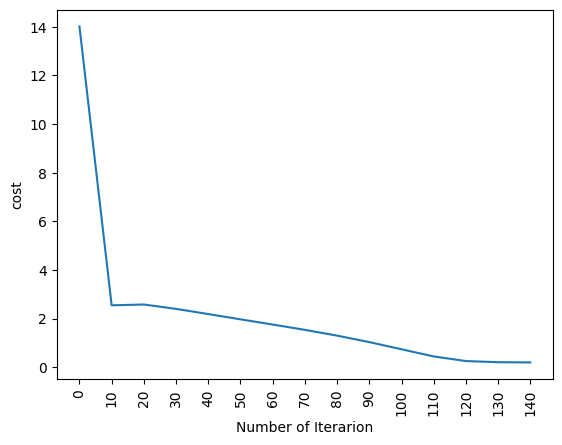

train accuracy:92.816091954023%
test accuracy:93.54838709677419%


In [25]:
logistic_regression(x_train, y_train ,x_test, y_test, learning_rate=0.01, num_iterations=150)

# 使用sklearn进行逻辑回归

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

这段代码是使用 Scikit-learn 库中的 `LogisticRegression` 类来进行逻辑回归模型的训练和评估。下面我将详细解释每一部分的功能和含义。

```python
from sklearn import linear_model
```
- 这行代码从 `sklearn` 库中导入 `linear_model` 模块，这是一个包含多种线性模型（包括逻辑回归）的模块。

```python
logreg = linear_model.LogisticRegression(random_state=42, max_iter=150)
```
- **`logreg`**: 这是一个 `LogisticRegression` 类的实例。该实例将用于拟合逻辑回归模型。
- **`random_state=42`**: 这是设置随机种子的参数。它确保运行代码时的结果是可重复的。选择一个随机种子（如 42）有助于在每次运行时获得一致的结果。
- **`max_iter=150`**: 这是模型的最大迭代次数。模型在训练时会进行多次迭代以优化参数，如果在 150 次迭代内没有收敛，则停止训练。

### 模型训练与评估
```python
print("test accuracy: {} ".format(logreg.fit(x_train.T, y_train.T).score(x_test.T, y_test.T)))
```
1. **`logreg.fit(x_train.T, y_train.T)`**:
   - `fit` 方法用于训练模型。这里使用了训练数据 `x_train` 和对应的标签 `y_train`。
   - 注意 `x_train.T` 和 `y_train.T` 是对训练数据和标签的转置，这在某些情况下可能是必要的，具体的转置取决于数据的原始形状。
   
2. **`.score(x_test.T, y_test.T)`**:
   - `score` 方法用于评估模型的性能。它返回模型在给定测试集 `x_test` 和标签 `y_test` 上的准确率。
   - 准确率是正确预测的样本占总样本的比例。

3. **`print(...)`**:
   - 将计算出的测试准确率格式化并打印出来。

### 训练集的准确率
```python
print("train accuracy: {} ".format(logreg.fit(x_train.T, y_train.T).score(x_train.T, y_train.T)))
```
这一行与上面相似，但它计算的是训练集的准确率：

1. **`logreg.fit(x_train.T, y_train.T)`**: 再次调用 `fit` 来训练模型，虽然这是不必要的，因为模型已经在上一步训练过了。通常应该在训练后直接使用 `score`，避免重复训练。
2. **`.score(x_train.T, y_train.T)`**: 计算并返回训练集的准确率。
3. **`print(...)`**: 输出训练准确率。

### 总结
- 这段代码使用 Scikit-learn 库来进行逻辑回归。它包含了模型的初始化、训练、及评估过程。
- 需要注意的是，模型在训练后可以直接调用 `score` 方法，而不必重复训练，这样更高效。
- 代码输出了测试集和训练集的准确率，帮助你了解模型在不同数据集上的表现。


In [26]:
from sklearn import linear_model
logreg = linear_model.LogisticRegression(random_state = 42,max_iter= 150)
print("test accuracy: {} ".format(logreg.fit(x_train.T, y_train.T).score(x_test.T, y_test.T)))
print("train accuracy: {} ".format(logreg.fit(x_train.T, y_train.T).score(x_train.T, y_train.T)))

test accuracy: 0.967741935483871 
train accuracy: 1.0 


# 人工神经网络

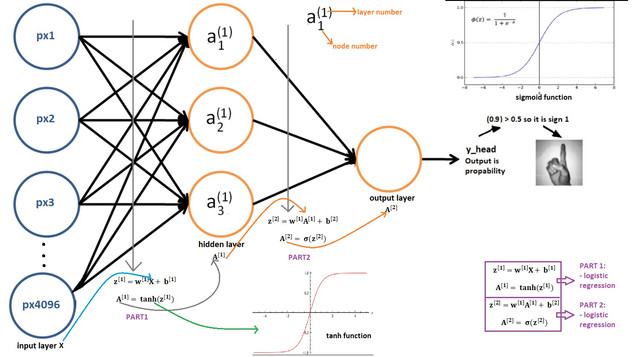

In [27]:
def initialize_parameters_and_layer_sizes_NN(x_train, y_train):
    parameters = {"weight1":np.random.randn(3, x_train.shape[0])*0.1,
                 "bias1":np.zeros((3,1)),
                 "weight2":np.random.randn(y_train.shape[0], 3) * 0.1,
                 "bias2":np.zeros((y_train.shape[0], 1))}
    
    return parameters

In [39]:
x_train.shape

(348, 4096)

In [40]:
y_train.shape

(348, 1)

In [47]:
weight_test1 = np.random.randn(3, x_train.shape[0])*0.1
test1 = np.dot(weight_test1, x_train)
test1.shape

(3, 4096)

In [48]:
test2 = np.tanh(test)
test2.shape

(3, 4096)

In [49]:
weight_test2 = np.random.randn(y_train.shape[0], 3) * 0.1
test3 = np.dot(weight_test2, test2)
test3.shape, weight_test2.shape

((348, 4096), (348, 3))

In [50]:
test4 = sigmoid(test3)
test4.shape

(348, 4096)

## 前向传播

In [28]:
def forward_propagation_NN(x_train, parameters):
    Z1 = np.dot(parameters["weight1"], x_train) + parameters["bias1"]
    A1 = np.tanh(Z1)
    Z2 = np.dot(parameters["weight2"], A1) + parameters["bias2"]
    A2 = sigmoid(Z2)
    
    cache = {"Z1":Z1, 
            "A1":A1,
            "Z2":Z2,
            "A2":A2}
    
    return A2, cache

## Loss function and Cost function

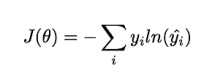

In [29]:
def compute_cost_NN(A2, Y, parameters):
    logprobs = np.multiply(np.log(A2), Y)
    cost = -np.sum(logprobs) / Y.shape[1]
    
    return cost

## 向后传播

`backward_propagation_NN` 是一个实现反向传播算法的函数，通常用于神经网络的训练过程。下面是对每一行代码的详细解释：

```python
def backward_propagation_NN(parameters, cache, X, Y):
```
这一行定义了一个名为 `backward_propagation_NN` 的函数，它接受四个参数：
- `parameters`: 包含神经网络权重和偏置的字典。
- `cache`: 包含前向传播过程中计算的信息（如激活值等），用于计算梯度。
- `X`: 输入数据，形状为 (特征数量, 样本数量)。
- `Y`: 真实标签，形状为 (输出类别数量, 样本数量)。

```python
    dZ2 = cache["A2"] - Y
```
这一行计算输出层的误差（或残差）。`dZ2` 表示输出层激活值减去真实标签 `Y`。这个步骤用于衡量预测与实际之间的差距。

```python
    dW2 = np.dot(dZ2, cache["A1"].T) / X.shape[1]
```
这一行计算输出层权重 `W2` 的梯度 `dW2`。它使用误差 `dZ2` 与前一层激活值 `cache["A1"]` 的转置进行点积，然后除以样本数量 `X.shape[1]` 以求得平均值。这是根据链式法则计算的梯度。

```python
    db2 = np.sum(dZ2, axis=1, keepdims=True) / X.shape[1]
```
这一行计算输出层偏置 `b2` 的梯度 `db2`。首先对 `dZ2` 在样本维度上（即按列）求和，得到每个输出单位的总误差，然后除以样本数量以获得平均值。

```python
    dZ1 = np.dot(parameters["weight2"].T, dZ2) * (1 - np.power(cache["A1"], 2))
```
这一行计算隐藏层的误差 `dZ1`。使用输出层的误差 `dZ2` 乘以权重 `W2` 的转置以反向传播误差信息。乘以 `1 - np.power(cache["A1"], 2)` 是因为如果使用了饱和的激活函数（比如 Tanh），这里是激活函数的导数（即 `f'(a) = 1 - a^2`）。

```python
    dW1 = np.dot(dZ1, X.T) / X.shape[1]
```
这一行计算隐藏层权重 `W1` 的梯度 `dW1`。它是通过将 `dZ1` 乘以输入数据 `X` 的转置进行点积得到的，随后除以样本数量以得到平均梯度。

```python
    db1 = np.sum(dZ1, axis=1, keepdims=True) / X.shape[1]
```
这一行计算隐藏层偏置 `b1` 的梯度 `db1`。同样，对 `dZ1` 的每个输出单位在样本维度上求和，然后除以样本数量以获得平均值。

```python
    grads = {"dweight1": dW1,
              "dbias1": db1,
              "dweight2": dW2,
              "dbias2": db2}
```
这一行创建一个字典 `grads`，其中存储了所有计算出来的梯度值，包括 `W1` 和 `W2` 的梯度，以及 `b1` 和 `b2` 的梯度。

```python
    return grads
```
最后，函数返回包含所有梯度的字典 `grads`，这些值将在后续的优化步骤中用于更新网络的参数。 

综上所述，这个函数实现了神经网络的反向传播计算，用于学习模型的权重和偏置，确保模型的输出尽量接近真实标签。


In [30]:
# Backward Propagation
def backward_propagation_NN(parameters, cache, X, Y):
 
    dZ2 = cache["A2"]-Y
    # dA2 / dw2 = (dA2 / dZ2) * (dZ2 / dw2)
    # Z2 = w2*A1 + b2
    # dZ2 / dw2 = A1
    # dw2 = dZ2 * A1
    dW2 = np.dot(dZ2,cache["A1"].T)/X.shape[1]
    db2 = np.sum(dZ2,axis =1,keepdims=True)/X.shape[1]
    # dZ1 = (dA2 / dZ2) * (dZ2 / dA1) * (dA1 / dZ1)
    dZ1 = np.dot(parameters["weight2"].T,dZ2)*(1 - np.power(cache["A1"], 2))
    # dW1 = dZ1 * x
    dW1 = np.dot(dZ1,X.T)/X.shape[1]
    db1 = np.sum(dZ1,axis =1,keepdims=True)/X.shape[1]
    grads = {"dweight1": dW1,
             "dbias1": db1,
             "dweight2": dW2,
             "dbias2": db2}
    return grads

## 更新参数

In [31]:
# update parameters
def update_parameters_NN(parameters, grads, learning_rate = 0.01):
    parameters = {"weight1": parameters["weight1"]-learning_rate*grads["dweight1"],
                  "bias1": parameters["bias1"]-learning_rate*grads["dbias1"],
                  "weight2": parameters["weight2"]-learning_rate*grads["dweight2"],
                  "bias2": parameters["bias2"]-learning_rate*grads["dbias2"]}
    
    return parameters

## 使用学习参数权重和偏差进行预测

In [32]:
def predict_NN(parameters, x_test):
    A2, cache = forward_propagation_NN(x_test, parameters)
    Y_prediction = np.zeros((1, x_test.shape[1]))
    
    for i in range(A2.shape[1]):
        if A2[0,i] <=0.5:
            Y_prediction[0,i] = 0
        else:
            Y_prediction[0, i] = 1
            
    return Y_prediction

## 创建模型

In [33]:
def two_layer_neural_network(x_train, y_train, x_test, y_test, num_iterations):
    
    cost_list = []
    index_list = []
    
    parameters = initialize_parameters_and_layer_sizes_NN(x_train, y_train)
    
    for i in range(0, num_iterations):
        
        A2, cache = forward_propagation_NN(x_train, parameters)
#         y_train = y_train[:, np.newaxis]
        cost = compute_cost_NN(A2, y_train, parameters)
        
        grads = backward_propagation_NN(parameters, cache, x_train, y_train)
        
        parameters = update_parameters_NN(parameters, grads)
        
        if i % 100 == 0:
            cost_list.append(cost)
            index_list.append(i)
            print("Cost after iteration %i: %f" % (i, cost))
            
    plt.plot(index_list, cost_list)
    plt.xlabel(index_list, rotation='vertical')
    plt.xlabel("Number of Iterarion")
    plt.ylabel("Cost")
    plt.show()
        
        # predict
    y_prediction_test = predict_NN(parameters,x_test)
    y_prediction_train = predict_NN(parameters,x_train)

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_train - y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))
    return parameters

Cost after iteration 0: 0.362543
Cost after iteration 100: 0.348869
Cost after iteration 200: 0.335152
Cost after iteration 300: 0.314689
Cost after iteration 400: 0.280886
Cost after iteration 500: 0.239147
Cost after iteration 600: 0.202149
Cost after iteration 700: 0.176739
Cost after iteration 800: 0.157484
Cost after iteration 900: 0.215437
Cost after iteration 1000: 0.117135
Cost after iteration 1100: 0.104752
Cost after iteration 1200: 0.094579
Cost after iteration 1300: 0.086036
Cost after iteration 1400: 0.078690
Cost after iteration 1500: 0.072299
Cost after iteration 1600: 0.066758
Cost after iteration 1700: 0.061921
Cost after iteration 1800: 0.057549
Cost after iteration 1900: 0.053396
Cost after iteration 2000: 0.049470
Cost after iteration 2100: 0.046161
Cost after iteration 2200: 0.043552
Cost after iteration 2300: 0.041409
Cost after iteration 2400: 0.039570


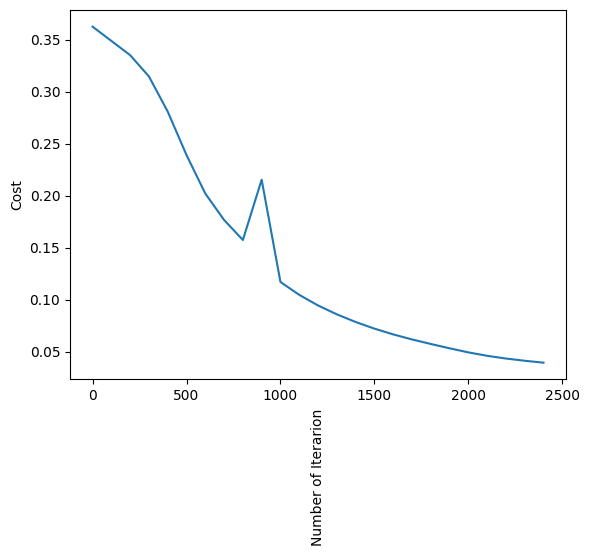

train accuracy: 99.71264367816092 %
test accuracy: 95.16129032258064 %


In [34]:
parameters = two_layer_neural_network(x_train, y_train,x_test,y_test, num_iterations=2500)

# L层神经网络

在本教程中，我们的模型将有 2 个隐藏层，分别具有 8 个和 4 个节点。因为当隐藏层和节点数量增加时，需要花费太多时间。

作为激活函数，我们将分别使用 relu（第一隐藏层）、relu（第二隐藏层）和 sigmoid（输出层）。

In [35]:
x_train, x_test, y_train, y_test = x_train.T, x_test.T, y_train.T, y_test.T

## 使用 keras 库实现

In [36]:
from scikeras.wrappers import KerasClassifier
# from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from keras.models import Sequential # initialize neural network library
from keras.layers import Dense # build our layers library

2024-08-03 10:34:53.643726: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-03 10:34:54.378765: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-03 10:34:55.173098: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


这段代码是使用 TensorFlow 和 Keras 构建一个简单的神经网络分类器，并使用交叉验证来评估其准确性。接下来，我将详细解释每一行代码的作用：

```python
def build_classifier():
```
- 这行定义了一个名为 `build_classifier` 的函数，该函数用于创建并返回一个神经网络分类器。

```python
    classifier = Sequential()  # initialize neural network
```
- 这行代码创建一个顺序模型（`Sequential`），这是 Keras 中构建神经网络的常用方法。顺序模型允许我们按层添加神经网络的层。

```python
    classifier.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu', input_dim = x_train.shape[1]))
```
- 这行代码向模型中添加了第一层，全连接层（Dense）。这一层有 8 个单元节点（`units=8`），使用均匀分布初始化权重（`kernel_initializer='uniform'`），激活函数为 ReLU（`activation='relu'`），输入维度被设置为训练数据（`x_train`）的特征数（`input_dim=x_train.shape[1]`）。

```python
    classifier.add(Dense(units = 4, kernel_initializer = 'uniform', activation = 'relu'))
```
- 这行代码添加了第二层，全连接层，拥有 4 个节点，其他参数设置同样使用均匀初始化和 ReLU 激活函数。由于这是第二层，所以不需要指定 `input_dim`，Keras 会自动处理输入。

```python
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
```
- 这行代码添加了第三层，这是输出层。该层只有 1 个单元，因为我们是进行二分类任务。它使用 Sigmoid 激活函数（`activation='sigmoid'`），这个函数将输出压缩到 0 到 1 之间，适合于二元分类。

```python
    classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
```
- 这行代码编译模型，设置优化器为 Adam（`optimizer='adam'`），损失函数为二元交叉熵（`loss='binary_crossentropy'`），这对于二分类问题是常用的损失函数。此外，指定了指标为准确率（`metrics=['accuracy']`），在训练和评估模型时会计算准确率。

```python
    return classifier
```
- 这行代码返回构建好的模型（分类器）。 

```python
classifier = KerasClassifier(build_fn = build_classifier, epochs = 100)
```
- 这行代码创建一个 `KerasClassifier` 对象，这个类将 Keras 模型封装成一个 scikit-learn 兼容的分类器。这里指定了 `build_fn` 参数为刚才定义的 `build_classifier` 函数，并设置训练的轮数（`epochs`）为 100。

```python
accuracies = cross_val_score(estimator = classifier, X = x_train, y = y_train, cv = 3)
```
- 这行代码使用交叉验证（`cross_val_score`）评估分类器的表现。`estimator` 参数是之前创建的模型，`X` 和 `y` 分别是训练数据和标签，`cv=3` 表示使用 3 折交叉验证，即将数据划分为 3 份进行训练和验证，每次用其中一份进行验证，其他两份进行训练。

```python
mean = accuracies.mean()
```
- 这行代码计算交叉验证过程中得到的准确率的平均值。

```python
variance = accuracies.std()
```
- 这行代码计算准确率的标准差，用于评估模型表现的稳定性。

```python
print("Accuracy mean: " + str(mean))
```
- 这行代码输出准确率的平均值。

```python
print("Accuracy variance: " + str(variance))
```
- 这行代码输出准确率的方差，帮助了解模型在不同折中的表现变化情况。

总结来说，这段代码定义并构建了一个简单的神经网络分类器，利用交叉验证评估其性能，并输出模型准确率的平均值和方差。


In [37]:
def build_classifier():
    classifier = Sequential() # initialize neural network
    classifier.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu', input_dim = x_train.shape[1]))
    classifier.add(Dense(units = 4, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier
classifier = KerasClassifier(build_fn = build_classifier, epochs = 100)
accuracies = cross_val_score(estimator = classifier, X = x_train, y = y_train, cv = 3)
mean = accuracies.mean()
variance = accuracies.std()
print("Accuracy mean: "+ str(mean))
print("Accuracy variance: "+ str(variance))

Epoch 1/100


2024-08-03 10:34:56.266608: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-08-03 10:34:56.677013: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


8/8 [==============================] - 0s 2ms/step - loss: 0.6934 - accuracy: 0.4914
Epoch 2/100
8/8 [==============================] - 0s 1ms/step - loss: 0.6921 - accuracy: 0.5043
Epoch 3/100
8/8 [==============================] - 0s 1ms/step - loss: 0.6919 - accuracy: 0.5043
Epoch 4/100
8/8 [==============================] - 0s 1ms/step - loss: 0.6908 - accuracy: 0.5216
Epoch 5/100
8/8 [==============================] - 0s 975us/step - loss: 0.6893 - accuracy: 0.5086
Epoch 6/100
8/8 [==============================] - 0s 1ms/step - loss: 0.6866 - accuracy: 0.5905
Epoch 7/100
8/8 [==============================] - 0s 918us/step - loss: 0.6838 - accuracy: 0.5043
Epoch 8/100
8/8 [==============================] - 0s 1ms/step - loss: 0.6751 - accuracy: 0.5043
Epoch 9/100
8/8 [==============================] - 0s 1ms/step - loss: 0.6663 - accuracy: 0.5043
Epoch 10/100
8/8 [==============================] - 0s 1ms/step - loss: 0.6544 - accuracy: 0.5043
Epoch 11/100
8/8 [===================

Epoch 84/100
8/8 [==============================] - 0s 1ms/step - loss: 0.0571 - accuracy: 0.9871
Epoch 85/100
8/8 [==============================] - 0s 936us/step - loss: 0.0593 - accuracy: 0.9828
Epoch 86/100
8/8 [==============================] - 0s 933us/step - loss: 0.0752 - accuracy: 0.9698
Epoch 87/100
8/8 [==============================] - 0s 929us/step - loss: 0.0661 - accuracy: 0.9784
Epoch 88/100
8/8 [==============================] - 0s 859us/step - loss: 0.0812 - accuracy: 0.9698
Epoch 89/100
8/8 [==============================] - 0s 852us/step - loss: 0.0541 - accuracy: 0.9741
Epoch 90/100
8/8 [==============================] - 0s 857us/step - loss: 0.0543 - accuracy: 0.9871
Epoch 91/100
8/8 [==============================] - 0s 938us/step - loss: 0.0533 - accuracy: 0.9784
Epoch 92/100
8/8 [==============================] - 0s 843us/step - loss: 0.0624 - accuracy: 0.9828
Epoch 93/100
8/8 [==============================] - 0s 950us/step - loss: 0.0501 - accuracy: 0.9828
Ep

8/8 [==============================] - 0s 920us/step - loss: 0.2776 - accuracy: 0.9655
Epoch 66/100
8/8 [==============================] - 0s 821us/step - loss: 0.2715 - accuracy: 0.9698
Epoch 67/100
8/8 [==============================] - 0s 1ms/step - loss: 0.2696 - accuracy: 0.9698
Epoch 68/100
8/8 [==============================] - 0s 823us/step - loss: 0.2694 - accuracy: 0.9784
Epoch 69/100
8/8 [==============================] - 0s 787us/step - loss: 0.2746 - accuracy: 0.9655
Epoch 70/100
8/8 [==============================] - 0s 818us/step - loss: 0.2774 - accuracy: 0.9784
Epoch 71/100
8/8 [==============================] - 0s 896us/step - loss: 0.2623 - accuracy: 0.9741
Epoch 72/100
8/8 [==============================] - 0s 875us/step - loss: 0.2662 - accuracy: 0.9784
Epoch 73/100
8/8 [==============================] - 0s 929us/step - loss: 0.2607 - accuracy: 0.9741
Epoch 74/100
8/8 [==============================] - 0s 1ms/step - loss: 0.2599 - accuracy: 0.9784
Epoch 75/100
8/8 

8/8 [==============================] - 0s 824us/step - loss: 0.3419 - accuracy: 0.9353
Epoch 48/100
8/8 [==============================] - 0s 808us/step - loss: 0.3366 - accuracy: 0.9612
Epoch 49/100
8/8 [==============================] - 0s 842us/step - loss: 0.3417 - accuracy: 0.9267
Epoch 50/100
8/8 [==============================] - 0s 886us/step - loss: 0.3367 - accuracy: 0.9784
Epoch 51/100
8/8 [==============================] - 0s 867us/step - loss: 0.3353 - accuracy: 0.9397
Epoch 52/100
8/8 [==============================] - 0s 845us/step - loss: 0.3256 - accuracy: 0.9440
Epoch 53/100
8/8 [==============================] - 0s 1ms/step - loss: 0.3263 - accuracy: 0.9784
Epoch 54/100
8/8 [==============================] - 0s 931us/step - loss: 0.3268 - accuracy: 0.9224
Epoch 55/100
8/8 [==============================] - 0s 887us/step - loss: 0.3324 - accuracy: 0.9784
Epoch 56/100
8/8 [==============================] - 0s 861us/step - loss: 0.3166 - accuracy: 0.9483
Epoch 57/100
8/